In [3]:
import numpy as np # linear algebra
from PIL import Image # Image tools
import matplotlib.pyplot as plt # Plotting Image

## Loading Original Image

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

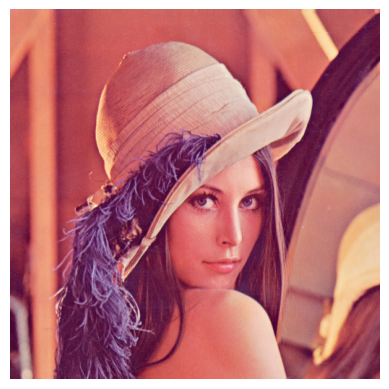

In [4]:
path = "lena.png"
img = Image.open(path)
plt.imshow(img)
plt.axis("off")

In [5]:
print(img.size) # Image size in pixels

(512, 512)


## Converting Image into Matrix

In [6]:
A = np.array(img) # Colour Images have 3 channels (R, G, B)
A.shape

(512, 512, 3)

In [7]:
A.dtype

dtype('uint8')

In [8]:
R = A[:, :, 0]
G = A[:, :, 1]
B = A[:, :, 2]

In [9]:
# Converting uint8(0-255) to float64 cause it can overflow
R = R.astype(np.float64)
G = G.astype(np.float64)
B = B.astype(np.float64)
print(R.dtype, G.dtype, B.dtype)

float64 float64 float64


In [10]:
# Image side length = N
N = R.shape[0]
N

512

## Build the DCT basis matrix

The 2D DCT-II basis matrix $C$ is defined element-wise as:

$$
C[m, n] = \alpha(m) \cdot \cos\left( \frac{\pi (2n + 1) m}{2N} \right)
$$

where $m, n = 0, 1, \dots, N-1$, and the normalization constant $\alpha(m)$ is:

$$
\alpha(m) =
\begin{cases}
\sqrt{\dfrac{1}{N}}, & m = 0 \\[2mm]
\sqrt{\dfrac{2}{N}}, & m \neq 0
\end{cases}
$$

- $m = 0$ gives the **DC term** — a constant basis vector (average brightness).
- $m > 0$ gives **AC terms** — cosine waves of increasing frequency (fine detail, edges).

In [11]:
# Computing the basis change matrix C
C = np.zeros((N, N), dtype = np.float64)
for m in range(N):
    for n in range(N):
        if m == 0:
            alpha = np.sqrt(1/N)
        else:
            alpha = np.sqrt(2/N)
        C[m, n] = alpha * np.cos((np.pi*((2*n)+1)*m)/(2*N))

Each row of $C$ is one such basis vector. Since these vectors are mutually orthogonal and individually normalized (unit length), $C$ is an **orthonormal matrix**, meaning:

$$
C^\top C = I
$$

This orthonormality is what makes the transform reversible — applying $C$ forward and $C^\top$ backward exactly recovers the original signal (aside from any coefficients we deliberately zero out for compression).

In [12]:
# Checking Orthogonality of C
I = C.T @ C
print(np.allclose(I, np.eye(N)))

True


## Apply the forward DCT to each channel

Each channel (a 2D array of pixel intensities) is transformed into the frequency domain using the basis matrix $C$:

$$
D = C^\top \, A \, C
$$

where $A$ is the original channel (e.g. $R$, $G$, or $B$), and $D$ is the resulting matrix of DCT coefficients — same shape as $A$, but now representing *frequency content* instead of *pixel intensity*.

Applied per channel:

$$
D_R = C^\top R \, C, \qquad D_G = C^\top G \, C, \qquad D_B = C^\top B \, C
$$

In $D$, low-frequency information (broad shapes, smooth gradients) is concentrated near the top-left corner $D[0,0]$, and high-frequency information (fine detail, sharp edges) appears toward the bottom-right.

In [13]:
# Lossless conversion by changing basis
D_R = C.T @ R @ C
D_G = C.T @ G @ C
D_B = C.T @ B @ C
print(D_R[:4, :4])
print(D_R.shape)

[[ 7.69710750e+04 -2.67782812e+04  1.62860456e+04 -5.85331072e+03]
 [-1.76274131e+04  9.28909869e+03 -7.95872671e+03  4.06757586e+01]
 [ 1.31066252e+04 -8.63125497e+03  5.24126112e+03 -3.94372131e+02]
 [-9.66341073e+03  5.38236278e+03 -1.46297638e+03 -7.26262137e+02]]
(512, 512)


## Visualising frequencies and noise around the image

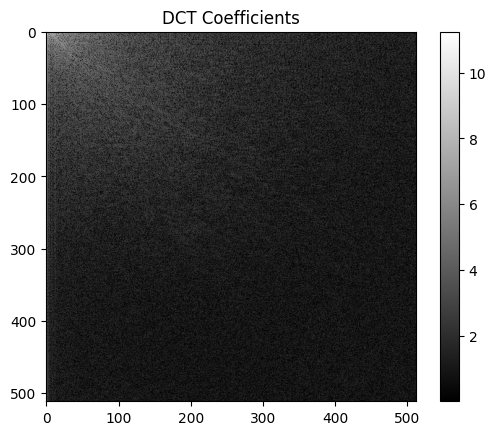

In [14]:
# Low frequency / high energy is concentrated at top left
plt.imshow(np.log(np.abs(D_R) + 1), cmap="gray")
plt.title("DCT Coefficients")
plt.colorbar()

In [15]:
# Choosing how much of top-left low freq coefficients we need
k = 128

In [16]:
# Creating a zero matrix for new basis
D_R_compressed = np.zeros_like(D_R)
D_G_compressed = np.zeros_like(D_G)
D_B_compressed = np.zeros_like(D_B)

# Assigning them top-left k values of new basis
D_R_compressed[:k, :k] = D_R[:k, :k]
D_G_compressed[:k, :k] = D_G[:k, :k]
D_B_compressed[:k, :k] = D_B[:k, :k]

## Invert the DCT to reconstruct the (lossy) image

Since $C$ is orthonormal ($C^\top C = I$), the transform is invertible: multiplying by $C$ and $C^\top$ from the opposite sides recovers the spatial-domain image from the frequency-domain coefficients:

$$
A_{\text{compressed}} = C \, D_{\text{compressed}} \, C^\top
$$

Applied per channel, using the truncated coefficient matrices from the compression step:

$$
R_{\text{compressed}} = C \, D_{R,\text{compressed}} \, C^\top, \qquad
G_{\text{compressed}} = C \, D_{G,\text{compressed}} \, C^\top, \qquad
B_{\text{compressed}} = C \, D_{B,\text{compressed}} \, C^\top
$$

Because $D_{\text{compressed}}$ has most of its high-frequency entries zeroed out, this reconstruction is only an **approximation** of the original channel — the smaller $K$ was, the more information was discarded, and the more this reconstruction deviates from $A$.

In [17]:
# Reconstructing with new basis
R_compressed = C @ D_R_compressed @ C.T
G_compressed = C @ D_G_compressed @ C.T
B_compressed = C @ D_B_compressed @ C.T
R_compressed.shape

(512, 512)

In [18]:
# Clipping to 8 bit pixel range (0-255)
R_compressed = np.clip(R_compressed, 0, 255)
G_compressed = np.clip(G_compressed, 0, 255)
B_compressed = np.clip(B_compressed, 0, 255)

# Converting back to uint8
R_compressed = R_compressed.astype(np.uint8)
G_compressed = G_compressed.astype(np.uint8)
B_compressed = B_compressed.astype(np.uint8)

# Combining all channels into single matrix
A_compressed = np.stack((R_compressed, G_compressed, B_compressed), axis = 2)

## Comparing Original and Compressed Images

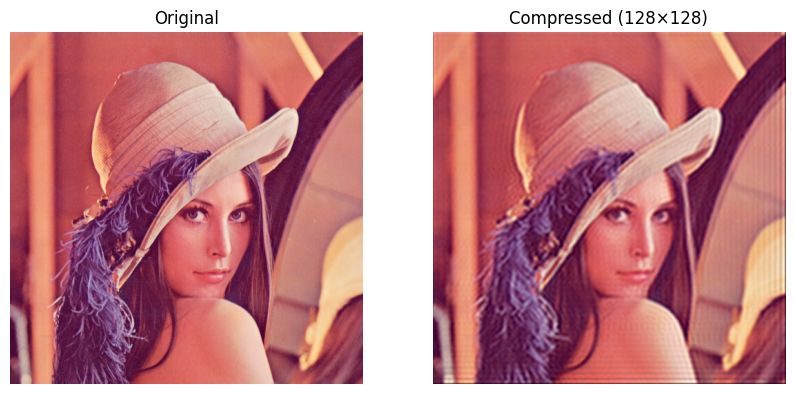

In [19]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(A)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(A_compressed)
plt.title(f"Compressed ({k}×{k})")
plt.axis("off")

plt.show()